In [9]:
import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

dfo = pd.read_csv('netflix_titles.csv')

In [10]:
df = dfo.copy()
print(df.shape)
print(df.dtypes)

(8807, 12)
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object


In [52]:
#посмотрел сколько пропусков в каждом столбце
print(df.isnull().sum())

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
year_added      0
dtype: int64


In [51]:
#просмотр данных
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021


In [53]:
#просмотрел типы данных в столбцах
df.dtypes

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int32
rating          object
duration        object
listed_in       object
description     object
year_added       int32
dtype: object

In [54]:
#заполнил пустые значения
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['date_added'] = df['date_added'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Unknown')
df['duration'] = df['duration'].fillna('Unknown')

      type  amount
0    Movie    6131
1  TV Show    2676


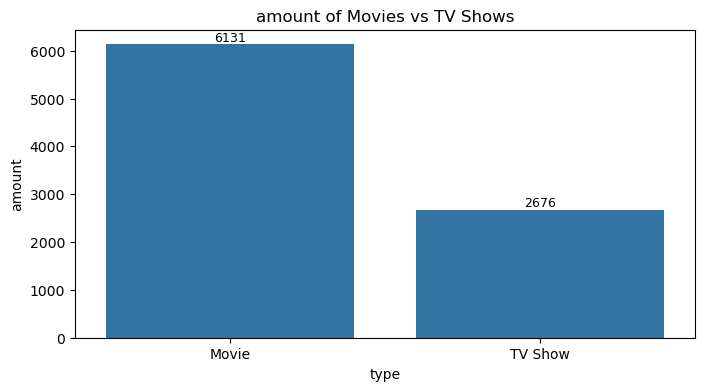

In [47]:
#просматриваю сколько видов контента есть и по сколько, далее вывел в график в график
amnt = df.groupby('type')['title'].count().reset_index()
amnt.columns = ['type', 'amount']
print(amnt)

plt.figure(figsize = (8, 4))
plt.title('amount of Movies vs TV Shows')
xt = sns.barplot(data = amnt, x = 'type', y = 'amount')
for z in xt.containers:
    xt.bar_label(z, fmt = '{:.0f}', fontsize = 9)

,rating,amount
11,TV-MA,3207
9,TV-14,2160
12,TV-PG,863
8,R,799
7,PG-13,490


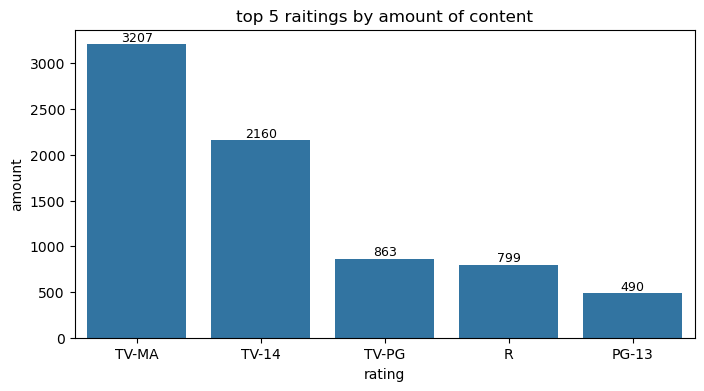

In [39]:
#вывел топ рейтингов по клоичеству, ввел переменную rte для дальнейшего вываода в график
rte = df.groupby('rating')['title'].count().reset_index()
rte.columns = ['rating', 'amount']
rait = rte.sort_values('amount', ascending = False).head(5)
display(rait)

plt.figure(figsize = (8, 4))
plt.title('top 5 raitings by amount of content')
xb = sns.barplot(data = rait, x = 'rating' , y = 'amount')
for o in xb.containers:
    xb.bar_label(o, fmt = '{:.0f}', fontsize = 9)
plt.show()

In [62]:
#вывел года добавления контента в отдельный столбец посредство среза
df['year_added'] = df['date_added'].str[-4:].where(df['date_added'] != 'Unknown', 'Unknown')
u = df.groupby('year_added')['title'].count().reset_index()
u.columns = ['year_added','films_added']
u.sort_values('films_added', ascending = False)

,year_added,films_added
11,2019,2016
12,2020,1879
10,2018,1649
13,2021,1498
9,2017,1188
8,2016,429
7,2015,82
6,2014,24
3,2011,13
5,2013,11


In [74]:
#преобразавал типы данных столбцов в интеджер чтобы далее реализовать идею с колонкой по разнице лет после релиза
df['year_added'] = df['year_added'].replace('Unknown', 0).astype(int)
df['release_year'] = df['release_year'].replace('Unknown', 0).astype(int)
print(df.dtypes)
df.head(3)

show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int32
rating          object
duration        object
listed_in       object
description     object
year_added       int32
aft_release      int32
dtype: object


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,aft_release
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,1
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,0


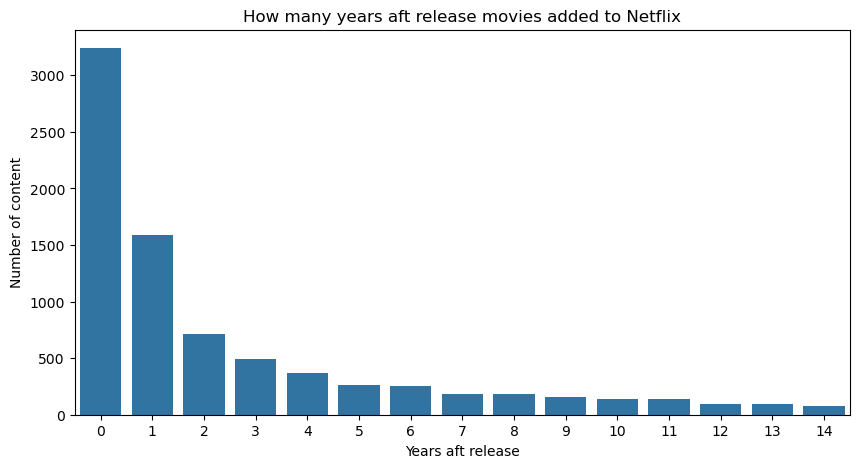

In [71]:
#добавил столбец указывающий на количество лет добавления контента на платформу, после релиза
df['aft_release'] = (df['year_added'] - df['release_year'])
dfd = df.groupby('aft_release')['title'].count().reset_index()
dfd.columns = ['years_aft_release', 'content']
dfd.sort_values('content', ascending=False)

top15 = dfd[dfd['years_aft_release'] >= 0].head(15)

#график указывает что большенство контента добавлялось в год релиза
plt.figure(figsize=(10, 5))
uu = sns.barplot(data=top15, x='years_aft_release', y='content')
plt.title('How many years aft release movies added to Netflix')
plt.xlabel('Years aft release')
plt.ylabel('Number of content')
plt.show()

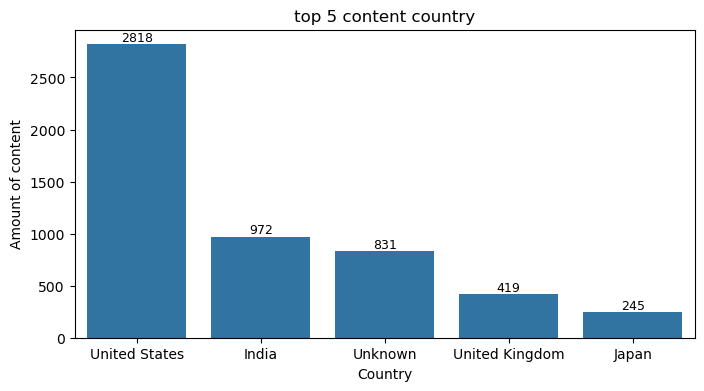

In [45]:
# просматриваю топ страны по производсту фильмов, для дальнейшего вывода в график
cntry = df.groupby('country')['title'].count().reset_index()
cntry.columns = ['country','title']

#вывожу график с топ странами по контенту
top5 = cntry.sort_values('title', ascending=False).head(5)
plt.figure(figsize = (8,4))
plt.title('top 5 content country')
xx = sns.barplot(data = top5, x = 'country', y = 'title')
for i in xx.containers:
    xx.bar_label(i, fmt = '{:.0f}', fontsize=9)
plt.xlabel('Country')
plt.ylabel('Amount of content')
plt.show()

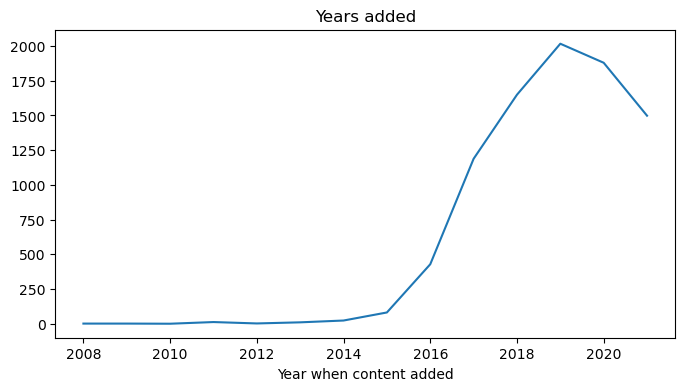

In [57]:
#вывел сколько контента было добавлено в каждый год и рисую график
year_data = df[df['year_added'] > 0].groupby('year_added')['title'].count()
plt.figure(figsize = (8, 4))
sns.lineplot(x = year_data.index, y = year_data.values)
plt.title('Years added')
plt.xlabel('Year when content added')
plt.show()